<a href="https://colab.research.google.com/github/aiyman14/Sch-Mgmt-661-Applications-of-AI-Models/blob/main/airbnb_miniproject_AA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Airbnb Mini-Project: Price Prediction with Neural Networks
**SCH-MGMT 661: Applications of AI Models**

This project extends Assignment 1 by comparing different neural network architectures and generating business-relevant insights for Airbnb price prediction.

---
## 1. Data Preparation
Reusing the cleaned dataset from Assignment 1 with additional features.

### 1.1 Data Loading and Initial Exploration

In [137]:
# Import required libraries for data analysis and visualization

import pandas as pd              # for data manipulation
import numpy as np               # for numerical operations
import matplotlib.pyplot as plt  # for plotting
import seaborn as sns            # for enhanced visualizations

# Set a default aesthetic style for plots
sns.set(style="whitegrid")

In [138]:
# import Airbnb Listing datasets for Asheville

listings_url = 'https://data.insideairbnb.com/united-states/nc/asheville/2024-06-21/data/listings.csv.gz'

# Load the datasets into DataFrames
listings_df = pd.read_csv(listings_url, compression='gzip')

Loading the dataset for data exploration and cleaning. Taken directly from Assignment 1.

In [139]:
# Display the first 10 rows
listings_df.head(10)

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,155305,https://www.airbnb.com/rooms/155305,20240621025915,2024-06-21,city scrape,Cottage! BonPaul + Sharky's Hostel,NaN,"We are within easy walk of pubs, breweries, mu...",https://a0.muscache.com/pictures/8880711/cf38d...,746673,...,4.75,4.92,4.58,NaN,f,8,2,2,4,2.78
1,156805,https://www.airbnb.com/rooms/156805,20240621025915,2024-06-21,city scrape,"Private Room ""Ader"" at BPS Hostel",NaN,"Easy walk to pubs, cafes, bakery, breweries, l...",https://a0.muscache.com/pictures/23447d55-fa7e...,746673,...,4.61,4.84,4.46,NaN,t,8,2,2,4,0.43
2,156926,https://www.airbnb.com/rooms/156926,20240621025915,2024-06-21,city scrape,"Mixed Dorm ""Top Bunk #1"" at BPS Hostel",This is a top bunk in the mixed dorm room<br /...,NaN,https://a0.muscache.com/pictures/5fa7178e-c514...,746673,...,4.77,4.78,4.78,NaN,t,8,2,2,4,2.17
3,197263,https://www.airbnb.com/rooms/197263,20240621025915,2024-06-21,city scrape,Tranquil Room & Private Bath,"This is a comfy, peaceful and clean room with ...",NaN,https://a0.muscache.com/pictures/miso/Hosting-...,961396,...,4.93,4.85,4.98,NaN,f,2,1,1,0,0.57
4,209068,https://www.airbnb.com/rooms/209068,20240621025915,2024-06-21,city scrape,Terrace Cottage,NaN,Our beautiful Grove Park Historic District clo...,https://a0.muscache.com/pictures/1829924/9f3bf...,1029919,...,4.98,4.94,4.79,NaN,f,1,1,0,0,0.42
5,246315,https://www.airbnb.com/rooms/246315,20240621025915,2024-06-21,city scrape,Asheville Dreamer's Cabin,"Hi there,<br />I am usually here half of each ...",NaN,https://a0.muscache.com/pictures/5908617/cfe79...,1292070,...,4.65,4.67,4.59,NaN,f,3,2,1,0,0.35
6,259576,https://www.airbnb.com/rooms/259576,20240621025915,2024-06-21,city scrape,"Private, Peaceful, and Free Goat Therapy","Privacy, peaceful, sweet comfortable apartment...",NaN,https://a0.muscache.com/pictures/3564e991-a326...,1362726,...,4.99,4.92,4.95,NaN,t,1,1,0,0,5.49
7,314540,https://www.airbnb.com/rooms/314540,20240621025915,2024-06-21,city scrape,Asheville Urban Farmhouse Entire Home 4.6 mi t...,Step back in time to this ethereal Dutch stone...,City vibes with country appeal. Peaceful neigh...,https://a0.muscache.com/pictures/miso/Hosting-...,381660,...,4.96,4.87,4.91,NaN,f,1,1,0,0,0.16
8,427497,https://www.airbnb.com/rooms/427497,20240621025915,2024-06-21,city scrape,Luxurious Mountain Guest Suite Apartment,Escape to our beautifully furnished luxurious ...,The neighborhood is peaceful and quiet. It has...,https://a0.muscache.com/pictures/4980195/acf66...,1909922,...,4.93,4.93,4.89,NaN,t,1,1,0,0,0.33
9,433646,https://www.airbnb.com/rooms/433646,20240621025915,2024-06-21,city scrape,Room in Historic Arts and Craft Home,This beautiful 1925's Art and Crafts home is l...,We are centrally located in the up and coming ...,https://a0.muscache.com/pictures/7235230/d9057...,1931430,...,4.86,4.32,4.51,NaN,f,2,0,2,0,0.77


In [140]:
# Explore columns, data types, and non-null counts
listings_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3031 entries, 0 to 3030
Data columns (total 75 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            3031 non-null   int64  
 1   listing_url                                   3031 non-null   object 
 2   scrape_id                                     3031 non-null   int64  
 3   last_scraped                                  3031 non-null   object 
 4   source                                        3031 non-null   object 
 5   name                                          3031 non-null   object 
 6   description                                   2939 non-null   object 
 7   neighborhood_overview                         2205 non-null   object 
 8   picture_url                                   3031 non-null   object 
 9   host_id                                       3031 non-null   i

In [141]:
# Display the shape of the DataFrame (rows, columns)
listings_df.shape

(3031, 75)

Initial data exploration. Taken directly from Assignment 1.

### 1.2 Filter Listings for Asheville

In [142]:
# Print all unique host locations in the dataset
print(listings_df['host_location'].unique())      # List all location names
print(len(listings_df['host_location'].unique())) # Total number of unique locations

['Asheville, NC' 'Fort Lauderdale, FL' nan 'Lexington, KY' 'Fletcher, NC'
 'Evanston, IL' 'Winston-Salem, NC' 'Sebring, FL' 'Austin, TX'
 'Chicago, IL' 'Weaverville, NC' 'North Carolina, United States'
 'Cartersville, GA' 'Newland, NC' 'Arden, NC' 'Candler, NC'
 'Mount Dora, FL' 'Savannah, GA' 'San Diego, CA' 'Miami, FL'
 'Wilmington, NC' 'Flat Rock, NC' 'Barnardsville, NC' 'Fayetteville, NC'
 'Lido Beach, NY' 'Charleston, SC' 'Laguna Beach, CA'
 'Peterborough, Canada' 'United States' 'Brevard, NC' 'Atlanta, GA'
 'Columbia, MD' 'Rocky Mount, NC' 'Woodfin, NC' 'Charlotte, NC'
 'Old Fort, NC' 'Swannanoa, NC' 'Floyds Knobs, IN' 'Saint Petersburg, FL'
 'Arvada, CO' 'Santa Fe, NM' 'Raleigh, NC' 'Mobile, AL' 'Sarasota, FL'
 'New York, United States' 'Boston, MA' 'San Francisco, CA'
 'Vitorino dos Piães, Portugal' 'Johnson City, TN' 'Roswell, GA'
 'Denver, CO' 'Myrtle Beach, SC' 'DeLand, FL' 'Hendersonville, NC'
 'Indianapolis, IN' 'Los Angeles, CA' 'Hemphill, TX' 'Pittsboro, NC'
 'Wake Fores

In [143]:
# Filter Listings for Asheville
asheville_df = listings_df[listings_df['host_location'] == 'Asheville, NC']

In [144]:
# Shape of the filtered dataset
asheville_df.shape

(2003, 75)

Ensure listings belong to hosts located in Asheville, NC. Kept all records with host_location as Asheville, dropped all rows with missing or different host_location values. Taken directly from Assignment 1.

### 1.3 Select Relevant Features

In [145]:
# Define the columns we want to keep and create a new dataframe with the selected columns
selected_columns = [
    'price', 'bathrooms','bedrooms', 'number_of_reviews',
    'room_type', 'host_identity_verified', 'host_is_superhost',
    'accommodates', 'review_scores_rating'
]

asheville_df = asheville_df[selected_columns]

In [146]:
# Preview the first few rows of the new dataframe
asheville_df.head()

,price,bathrooms,bedrooms,number_of_reviews,room_type,host_identity_verified,host_is_superhost,accommodates,review_scores_rating
0,$99.00,1.0,1.0,437,Entire home/apt,t,t,2,4.61
1,$66.00,2.5,1.0,67,Private room,t,t,2,4.52
2,$26.00,2.5,1.0,339,Shared room,t,t,1,4.70
3,$49.00,1.0,1.0,82,Private room,t,t,2,4.95
4,$100.00,1.0,1.0,65,Entire home/apt,t,t,4,4.89


Extended the selected features from W3 to include accommodates, review_scores_rating, and room_type. Taken directly from Assignment 1.

### 1.4 Handle Missing Values

In [147]:
# Check for missing values in each column
asheville_df.isnull().sum()

,0
price,100
bathrooms,100
bedrooms,13
number_of_reviews,0
room_type,0
host_identity_verified,0
host_is_superhost,28
accommodates,0
review_scores_rating,112


Check for missing values before applying imputation strategies. Taken directly from Assignment 1.

In [148]:
# Drop rows where the target variable (price) is missing and then re-check for missing values
asheville_df = asheville_df.dropna(subset=['price'])
asheville_df.isnull().sum()

,0
price,0
bathrooms,0
bedrooms,0
number_of_reviews,0
room_type,0
host_identity_verified,0
host_is_superhost,28
accommodates,0
review_scores_rating,108


Drop rows where the price value is missing. Taken directly from Assignment 1.

In [149]:
# Impute host_is_superhost using mode
asheville_df['host_is_superhost'] = asheville_df['host_is_superhost'].fillna(
    asheville_df['host_is_superhost'].mode()[0]
)
asheville_df.isnull().sum()

,0
price,0
bathrooms,0
bedrooms,0
number_of_reviews,0
room_type,0
host_identity_verified,0
host_is_superhost,0
accommodates,0
review_scores_rating,108


Impute host_is_superhost using mode. Taken directly from Assignment 1.

In [150]:
# Impute numerical missing values using mean or median, depending on data distribution
asheville_df['bedrooms'] = asheville_df['bedrooms'].fillna(asheville_df['bedrooms'].median())
asheville_df['bathrooms'] = asheville_df['bathrooms'].fillna(asheville_df['bathrooms'].mean())
asheville_df.isnull().sum()

,0
price,0
bathrooms,0
bedrooms,0
number_of_reviews,0
room_type,0
host_identity_verified,0
host_is_superhost,0
accommodates,0
review_scores_rating,108


Impute bedrooms using median and bathrooms using mean to fill missing values for numerical features except for review_scores_rating. Taken directly from Assignment 1.

In [151]:
# For review_scores_rating, replace missing values with 0 (indicating no reviews)
asheville_df['review_scores_rating'] = asheville_df['review_scores_rating'].fillna(0)

# Create a dummy variable (has_review_scores) to indicate whether a listing has a review
asheville_df['has_review_scores'] = (asheville_df['review_scores_rating'] > 0).astype(int)

asheville_df.isnull().sum()

,0
price,0
bathrooms,0
bedrooms,0
number_of_reviews,0
room_type,0
host_identity_verified,0
host_is_superhost,0
accommodates,0
review_scores_rating,0
has_review_scores,0


Replace missing values of review_scores_rating with 0. Then created a dummy variable has_review_scores to indicate whether a listing has a review. has_review_scores = 1 if review_scores_rating > 0, has_review_scores = 0 if review_scores_rating == 0 (no reviews). Taken directly from Assignment 1.

### 1.5 Fix Data Types and Encode Columns

In [152]:
# Check data types
asheville_df.dtypes

,0
price,object
bathrooms,float64
bedrooms,float64
number_of_reviews,int64
room_type,object
host_identity_verified,object
host_is_superhost,object
accommodates,int64
review_scores_rating,float64
has_review_scores,int64


In [153]:
# Convert price to Numeric
asheville_df['price'] = asheville_df['price'].replace(r'[\$,]', '', regex=True).astype(float)

Convert price from string to numeric for analysis. Taken directly from Assignment 1.

In [154]:
# Convert Boolean-like Columns
asheville_df['host_identity_verified'] = asheville_df['host_identity_verified'].map({'t': 1, 'f': 0})
asheville_df['host_is_superhost'] = asheville_df['host_is_superhost'].map({'t': 1, 'f': 0})

Dummy encode categorical variables host_identity_verified and host_is_superhost. Taken directly from Assignment 1.

In [155]:
# Encode Categorical Column

room_type_dummies = pd.get_dummies(asheville_df['room_type'], prefix='room_type', drop_first=True)
room_type_dummies = room_type_dummies.astype(int)

# Add new columns to the DataFrame
asheville_df = pd.concat([asheville_df, room_type_dummies], axis=1)
asheville_df.drop('room_type', axis=1, inplace=True)

asheville_df.head()

,price,bathrooms,bedrooms,number_of_reviews,host_identity_verified,host_is_superhost,accommodates,review_scores_rating,has_review_scores,room_type_Hotel room,room_type_Private room,room_type_Shared room
0,99.0,1.0,1.0,437,1,1,2,4.61,1,0,0,0
1,66.0,2.5,1.0,67,1,1,2,4.52,1,0,1,0
2,26.0,2.5,1.0,339,1,1,1,4.70,1,0,0,1
3,49.0,1.0,1.0,82,1,1,2,4.95,1,0,1,0
4,100.0,1.0,1.0,65,1,1,4,4.89,1,0,0,0


One-hot encode room_type due to multi-category. Taken directly from Assignment 1.

### 1.6 Handle Outliers

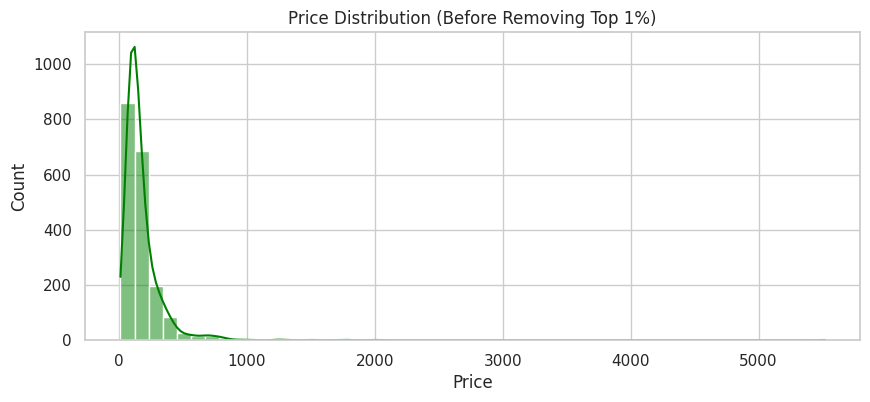

In [156]:
# Visualize the original price distribution
plt.figure(figsize=(10, 4))
sns.histplot(asheville_df['price'], bins=50, kde=True, color='green')
plt.title("Price Distribution (Before Removing Top 1%)")
plt.xlabel("Price")
plt.show()

In [157]:
# Remove top 1% of extreme price values
price_cap = asheville_df['price'].quantile(0.99)
asheville_df = asheville_df[asheville_df['price'] <= price_cap]

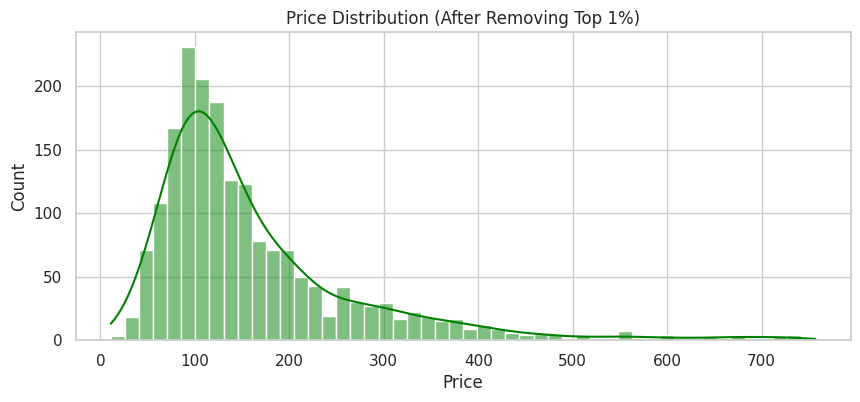

In [158]:
# Visualize the cleaned price distribution
plt.figure(figsize=(10, 4))
sns.histplot(asheville_df['price'], bins=50, kde=True, color='green')
plt.title("Price Distribution (After Removing Top 1%)")
plt.xlabel("Price")
plt.show()

Handle outliers by removing the top 1% of extreme price values. Taken directly from Assignment 1.

### 1.7 Descriptive Statistics

In [159]:
# Descriptive Statistics
asheville_df.describe()

,price,bathrooms,bedrooms,number_of_reviews,host_identity_verified,host_is_superhost,accommodates,review_scores_rating,has_review_scores,room_type_Hotel room,room_type_Private room,room_type_Shared room
count,1883.000000,1883.000000,1883.000000,1883.000000,1883.000000,1883.000000,1883.000000,1883.000000,1883.000000,1883.000000,1883.000000,1883.000000
mean,163.057886,1.498141,1.758895,132.887414,0.889538,0.770579,4.310674,4.630579,0.943707,0.000531,0.118959,0.003717
std,112.148534,0.800419,1.153136,161.222156,0.313548,0.420572,2.744065,1.137257,0.230548,0.023045,0.323826,0.060874
min,11.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,93.000000,1.000000,1.000000,20.000000,1.000000,1.000000,2.000000,4.850000,1.000000,0.000000,0.000000,0.000000
50%,127.000000,1.000000,1.000000,75.000000,1.000000,1.000000,4.000000,4.940000,1.000000,0.000000,0.000000,0.000000
75%,196.000000,2.000000,2.000000,183.000000,1.000000,1.000000,6.000000,4.980000,1.000000,0.000000,0.000000,0.000000
max,757.000000,7.000000,8.000000,1333.000000,1.000000,1.000000,16.000000,5.000000,1.000000,1.000000,1.000000,1.000000


---
## 2. Additional Features
New features added for the mini-project to enhance model performance. These are pulled from the original dataset (`listings_df`) using index alignment with our cleaned `asheville_df`.

In [160]:
# Reference the full Asheville data from the original dataset (still in memory)
# Using index alignment so only rows that survived cleaning get new feature values
asheville_full = listings_df[listings_df['host_location'] == 'Asheville, NC']

In [161]:
# Feature 1: amenities_count — count the number of amenities listed for each property
# The amenities column is stored as a string like '["Wifi", "Kitchen", "Free parking"]'
# We parse it by splitting on commas to get the count
asheville_df['amenities_count'] = asheville_full['amenities'].apply(
    lambda x: len(str(x).split(',')) if pd.notna(x) else 0
)

# Feature 2: host_total_listings_count — total number of properties managed by the host
asheville_df['host_total_listings_count'] = asheville_full['host_total_listings_count']

# Feature 3: minimum_nights — minimum stay requirement for the listing
asheville_df['minimum_nights'] = asheville_full['minimum_nights']

In [162]:
# Check for any missing values in the new features
print(asheville_df[['amenities_count', 'host_total_listings_count', 'minimum_nights']].isnull().sum())
print()

# Impute any missing values with median (safe default for skewed numeric data)
for col in ['amenities_count', 'host_total_listings_count', 'minimum_nights']:
    asheville_df[col] = asheville_df[col].fillna(asheville_df[col].median())

amenities_count              0
host_total_listings_count    0
minimum_nights               0
dtype: int64



In [163]:
# Quick summary of the new features
asheville_df[['amenities_count', 'host_total_listings_count', 'minimum_nights']].describe()

,amenities_count,host_total_listings_count,minimum_nights
count,1883.000000,1883.000000,1883.000000
mean,44.157727,24.231545,5.080722
std,14.416165,58.512290,9.954565
min,1.000000,1.000000,1.000000
25%,33.000000,1.000000,1.000000
50%,44.000000,3.000000,2.000000
75%,55.000000,8.000000,2.000000
max,88.000000,368.000000,90.000000


In [164]:
# Preview the updated dataframe with new features
asheville_df.head()

,price,bathrooms,bedrooms,number_of_reviews,host_identity_verified,host_is_superhost,accommodates,review_scores_rating,has_review_scores,room_type_Hotel room,room_type_Private room,room_type_Shared room,amenities_count,host_total_listings_count,minimum_nights
0,99.0,1.0,1.0,437,1,1,2,4.61,1,0,0,0,27,12,1
1,66.0,2.5,1.0,67,1,1,2,4.52,1,0,1,0,21,12,1
2,26.0,2.5,1.0,339,1,1,1,4.70,1,0,0,1,18,12,1
3,49.0,1.0,1.0,82,1,1,2,4.95,1,0,1,0,47,2,2
4,100.0,1.0,1.0,65,1,1,4,4.89,1,0,0,0,42,1,30


### Why These Features Were Chosen

Three additional features were selected to enhance the model beyond the Assignment 1 baseline:

**amenities_count** — Captures the overall "value offering" of a property. More amenities generally means a higher-quality experience and higher nightly rates.

**host_total_listings_count** — Distinguishes professional hosts (many properties) from individual hosts. Professional hosts often have different pricing strategies.

**minimum_nights** — Reflects pricing strategy. Short minimum stays (1–2 nights) target tourists at higher per-night rates, while longer minimums often offer discounted rates.

All three are fully populated in the raw dataset, avoiding additional imputation noise. Together they add property quality, host behavior, and booking strategy dimensions not captured by the Assignment 1 features.

### Brief EDA on New Features

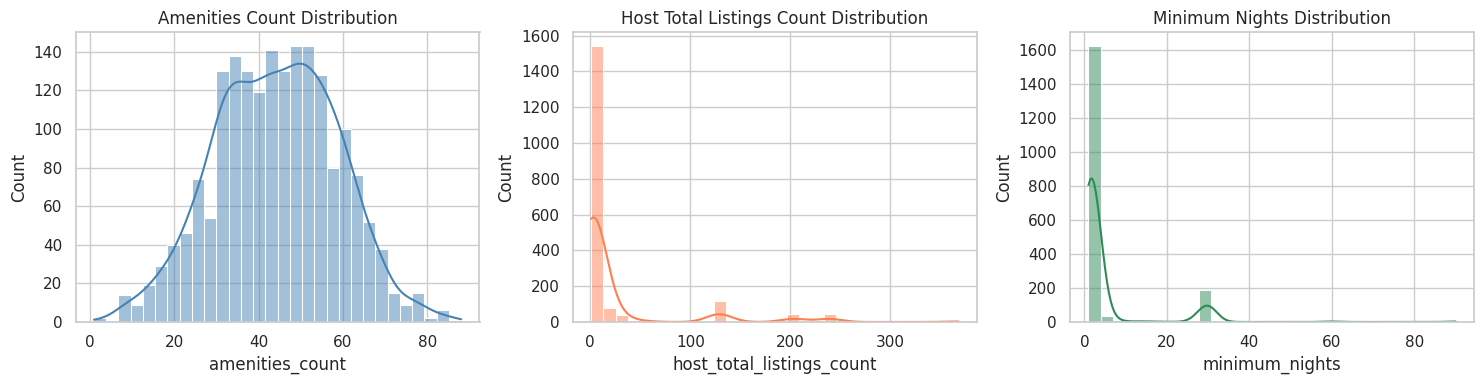

In [165]:
# Histograms of the new features
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(asheville_df['amenities_count'], bins=30, kde=True, color='steelblue', ax=axes[0])
axes[0].set_title('Amenities Count Distribution')

sns.histplot(asheville_df['host_total_listings_count'], bins=30, kde=True, color='coral', ax=axes[1])
axes[1].set_title('Host Total Listings Count Distribution')

sns.histplot(asheville_df['minimum_nights'], bins=30, kde=True, color='seagreen', ax=axes[2])
axes[2].set_title('Minimum Nights Distribution')

plt.tight_layout()
plt.show()

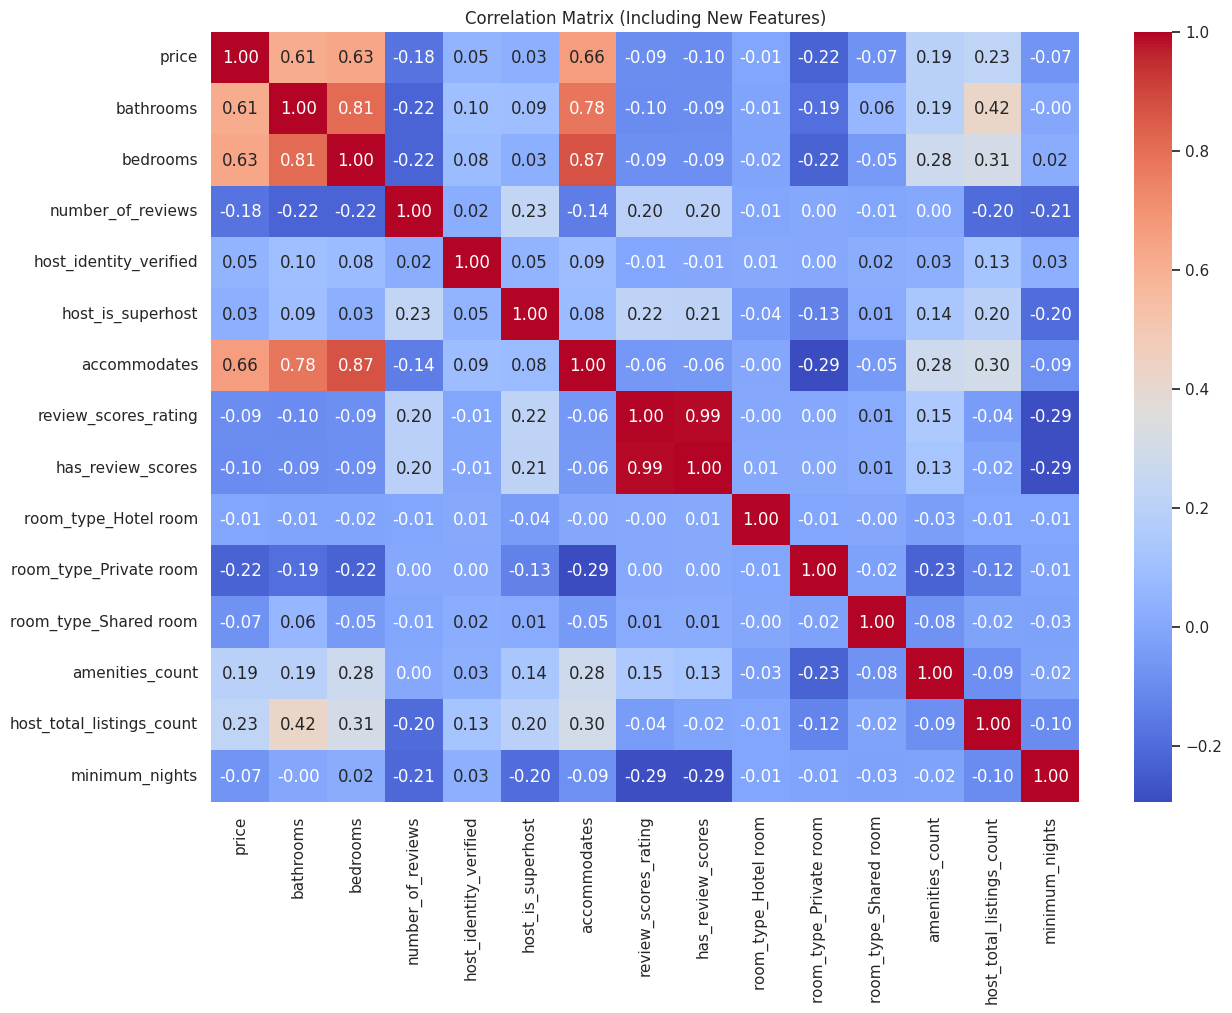

In [166]:
# Correlation matrix including new features
corr = asheville_df.corr()
plt.figure(figsize=(14, 10))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix (Including New Features)")
plt.show()

Brief overview of the new features. Amenities count and host_total_listings_count are right-skewed, indicating most listings have a moderate number of amenities and most hosts manage few properties. Minimum nights is heavily concentrated at low values (1–3 nights). The correlation matrix shows how the new features relate to price and to each other compared to the Assignment 1 features.

---
## 3. Modeling Preparation
Feature selection, train/test split, normalization, and helper functions.

In [167]:
# Imports required libraries for pre-processing and modeling

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Normalization, Input
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [168]:
# Baseline features (same as Assignment 1 — used for Model A and Model B)
features = ['bedrooms', 'bathrooms', 'number_of_reviews', 'host_is_superhost',
            'host_identity_verified', 'accommodates', 'review_scores_rating',
            'has_review_scores', 'room_type_Hotel room', 'room_type_Private room',
            'room_type_Shared room']
target = 'price'

# Enhanced features for Model C (baseline + new features)
features_enhanced = features + ['amenities_count', 'host_total_listings_count', 'minimum_nights']

Selecting baseline features (same as Assignment 1) for Models A and B, and an enhanced feature set including the new features for Model C.

In [169]:
# Define X and y for baseline models
X = asheville_df[features]
y = asheville_df[target]

# Train-Test Split (80/20, same as Assignment 1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define and Adapt Normalization Layer for baseline features
norm_layer = Normalization()
norm_layer.adapt(X_train.values)

In [170]:
# Define X and y for enhanced model (Model C)
# Use SAME train/test rows as baseline for fair comparison
X_enhanced = asheville_df[features_enhanced]

X_train_enh = X_enhanced.loc[X_train.index]
X_test_enh = X_enhanced.loc[X_test.index]

# Define and Adapt Normalization Layer for enhanced features
norm_layer_enh = Normalization()
norm_layer_enh.adapt(X_train_enh.values)

Train-test split with 80/20 ratio and random_state=42, same as Assignment 1. Separate normalization layers are adapted for baseline and enhanced feature sets. Enhanced model uses the same train/test row indices to ensure fair comparison.

In [171]:
# Helper function to evaluate a model on the test set
def eval_on_test(m, X_te, y_te):
    y_pred = m.predict(X_te, verbose=0).flatten()
    mae  = mean_absolute_error(y_te, y_pred)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    r2   = r2_score(y_te, y_pred)
    return mae, rmse, r2

In [172]:
# Helper function to plot training vs validation curves
def plot_training_curves(history, model_name="Model"):
    """Plots training vs validation MAE and MSE curves for a Keras model."""
    # Plot MAE
    plt.figure(figsize=(6, 4))
    plt.plot(history.history['mae'], label='Train MAE')
    plt.plot(history.history['val_mae'], label='Validation MAE')
    plt.xlabel('Epochs')
    plt.ylabel('MAE (Price)')
    plt.title(f'{model_name}: Training vs Validation MAE')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Plot Loss (MSE)
    plt.figure(figsize=(6, 4))
    plt.plot(history.history['loss'], label='Train Loss (MSE)')
    plt.plot(history.history['val_loss'], label='Validation Loss (MSE)')
    plt.xlabel('Epochs')
    plt.ylabel('MSE')
    plt.title(f'{model_name}: Training vs Validation Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

Helper functions for model evaluation and plotting, following the miniproject notebook structure. `eval_on_test` returns MAE, RMSE, and R² on the test set. `plot_training_curves` generates training vs validation MAE and loss (MSE) plots.

---
## 4. Model A: Baseline Neural Network (Assignment 1 Model)
Input → Dense(64, ReLU) → Dense(1)

In [173]:
# Build Model A (Baseline — same architecture as Assignment 1)
model_a = Sequential([
    Input(shape=(X_train.shape[1],)),
    norm_layer,
    Dense(64, activation='relu'),
    Dense(1)  # Regression output
])

# Compile Model A
model_a.compile(optimizer='adam', loss='mse', metrics=['mae'])

model_a.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization_2 (Normalization) │ (None, 11)             │            23 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 856 (3.35 KB)

 Trainable params: 833 (3.25 KB)

 Non-trainable params: 23 (96.00 B)

In [174]:
# Train Model A
hist_a = model_a.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=70,
    verbose=1
)

Epoch 1/70
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 38037.8555 - mae: 161.0723 - val_loss: 40576.0312 - val_mae: 165.2803
Epoch 2/70
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 37646.4180 - mae: 160.0378 - val_loss: 40112.3164 - val_mae: 164.1803
Epoch 3/70
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 37174.3750 - mae: 158.8358 - val_loss: 39549.3164 - val_mae: 162.8566
Epoch 4/70
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 36592.9219 - mae: 157.3556 - val_loss: 38825.3203 - val_mae: 161.1915
Epoch 5/70
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 35867.7891 - mae: 155.5032 - val_loss: 37945.2422 - val_mae: 159.1452
Epoch 6/70
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 34974.5117 - mae: 153.2585 - val_loss: 36875.6406 - val_mae: 156.6478
Epoch 7/70
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 33904.2578 - mae: 150.5572 - val_loss: 35622.8750 - val_mae: 153.6767
Epoch 8/70
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 32663.1562 - mae: 147.3492 - val_loss: 34144.7

In [175]:
# Evaluate Model A on test set
mae_a, rmse_a, r2_a = eval_on_test(model_a, X_test, y_test)
print(f"Model A (Baseline) -> MAE: {round(mae_a, 2)}  RMSE: {round(rmse_a, 2)}  R²: {round(r2_a, 2)}")

Model A (Baseline) -> MAE: 56.55  RMSE: 82.88  R²: 0.49


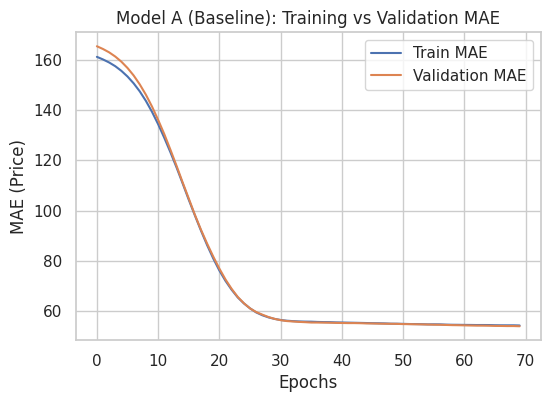

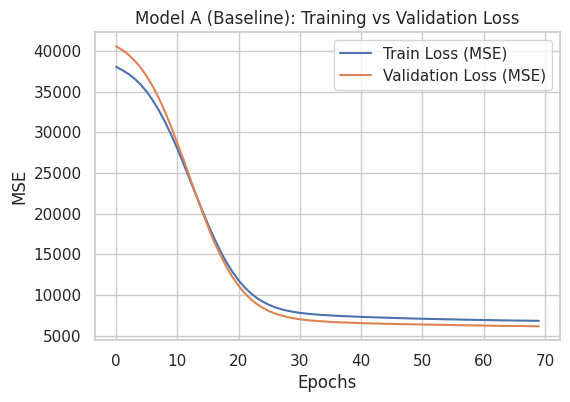

In [176]:
# Plot training curves for Model A
plot_training_curves(hist_a, model_name="Model A (Baseline)")

Model A is the baseline from Assignment 1. Single hidden layer with 64 nodes and ReLU activation, trained for 70 epochs with 20% validation split.

---
## 5. Model B: Deeper Neural Network
Input → Dense(128, ReLU) → Dense(64, ReLU) → Dense(1)

In [177]:
# Build Model B (Deeper Neural Network)
model_b = Sequential([
    Input(shape=(X_train.shape[1],)),
    norm_layer,
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(1)  # Regression output
])

# Compile Model B
model_b.compile(optimizer='adam', loss='mse', metrics=['mae'])

model_b.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization_2 (Normalization) │ (None, 11)             │            23 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,880 (38.60 KB)

 Trainable params: 9,857 (38.50 KB)

 Non-trainable params: 23 (96.00 B)

In [178]:
# Train Model B
hist_b = model_b.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=70,
    verbose=1
)

Epoch 1/70
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 37693.0352 - mae: 159.9760 - val_loss: 39473.5898 - val_mae: 162.2050
Epoch 2/70
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 34930.9922 - mae: 151.9308 - val_loss: 34272.9180 - val_mae: 148.2312
Epoch 3/70
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 27049.1934 - mae: 128.7803 - val_loss: 22304.6797 - val_mae: 113.2760
Epoch 4/70
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 15004.8408 - mae: 87.1163 - val_loss: 10059.5801 - val_mae: 70.6086
Epoch 5/70
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 8395.9834 - mae: 60.2528 - val_loss: 7149.5522 - val_mae: 57.5435
Epoch 6/70
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 7688.7559 - mae: 57.1939 - val_loss: 6866.8291 - val_mae: 56.7314
Epoch 7/70
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 7466.3389 - mae: 56.5733 - val_loss: 6703.2676 - val_mae: 56.1367
Epoch 8/70
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 7325.3521 - mae: 55.8522 - val_loss: 6574.8003 - val_mae: 55

In [179]:
# Evaluate Model B on test set
mae_b, rmse_b, r2_b = eval_on_test(model_b, X_test, y_test)
print(f"Model B (Deeper)   -> MAE: {round(mae_b, 2)}  RMSE: {round(rmse_b, 2)}  R²: {round(r2_b, 2)}")

Model B (Deeper)   -> MAE: 55.14  RMSE: 80.85  R²: 0.51


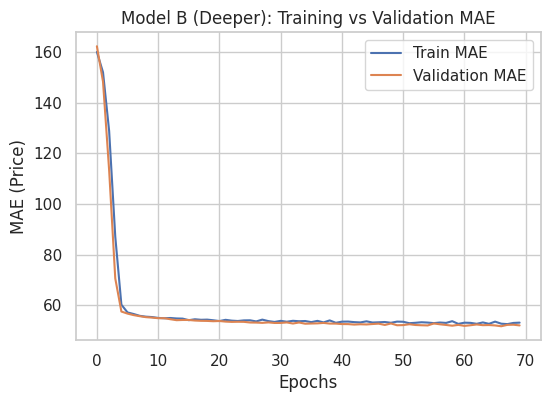

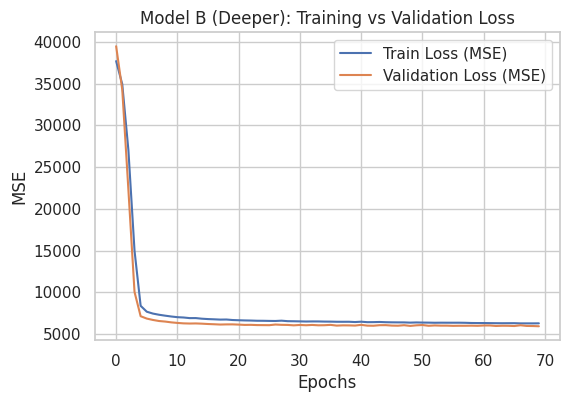

In [180]:
# Plot training curves for Model B
plot_training_curves(hist_b, model_name="Model B (Deeper)")

Model B adds a second hidden layer (128 → 64 nodes) to increase model capacity. Uses the same baseline features and training setup as Model A to isolate the effect of deeper architecture.

---
## 6. Model C: Enhanced Features + Early Stopping
Includes new features (amenities_count, host_total_listings_count, minimum_nights) + Input → Dense(128, ReLU) → Dense(64, ReLU) → Dense(1) + EarlyStopping

In [181]:
# Build Model C (Enhanced Features + Early Stopping)
model_c = Sequential([
    Input(shape=(X_train_enh.shape[1],)),
    norm_layer_enh,
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(1)  # Regression output
])

# Compile Model C
model_c.compile(optimizer='adam', loss='mse', metrics=['mae'])

model_c.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization_3 (Normalization) │ (None, 14)             │            29 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │         1,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,270 (40.12 KB)

 Trainable params: 10,241 (40.00 KB)

 Non-trainable params: 29 (120.00 B)

In [182]:
# EarlyStopping callback to prevent overfitting
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Train Model C with enhanced features and early stopping
hist_c = model_c.fit(
    X_train_enh, y_train,
    validation_split=0.2,
    epochs=70,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/70
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 37374.3008 - mae: 159.0378 - val_loss: 38732.3633 - val_mae: 160.2497
Epoch 2/70
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 33535.9453 - mae: 148.0479 - val_loss: 31698.7344 - val_mae: 141.7050
Epoch 3/70
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 23951.2461 - mae: 119.6298 - val_loss: 18060.7246 - val_mae: 102.0023
Epoch 4/70
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 12417.8252 - mae: 77.5327 - val_loss: 8628.5986 - val_mae: 64.7496
Epoch 5/70
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 7977.6079 - mae: 57.6162 - val_loss: 7093.5366 - val_mae: 56.9434
Epoch 6/70
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 7335.6611 - mae: 55.1819 - val_loss: 6727.4717 - val_mae: 56.0273
Epoch 7/70
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 7066.1113 - mae: 54.6886 - val_loss: 6525.9204 - val_mae: 55.2813
Epoch 8/70
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6907.4956 - mae: 53.8611 - val_loss: 6391.7104 - val_mae: 54.

In [183]:
# Evaluate Model C on test set (using enhanced features)
mae_c, rmse_c, r2_c = eval_on_test(model_c, X_test_enh, y_test)
print(f"Model C (Enhanced) -> MAE: {round(mae_c, 2)}  RMSE: {round(rmse_c, 2)}  R²: {round(r2_c, 2)}")

Model C (Enhanced) -> MAE: 55.54  RMSE: 83.39  R²: 0.48


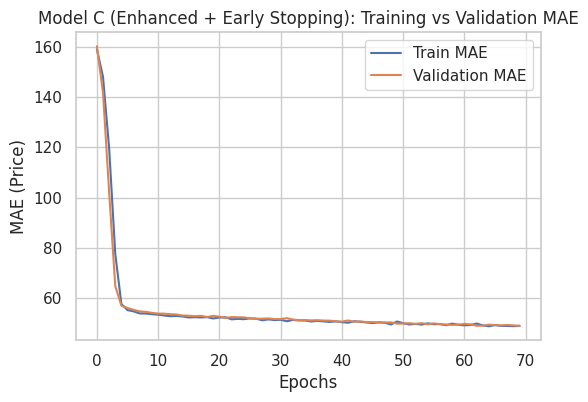

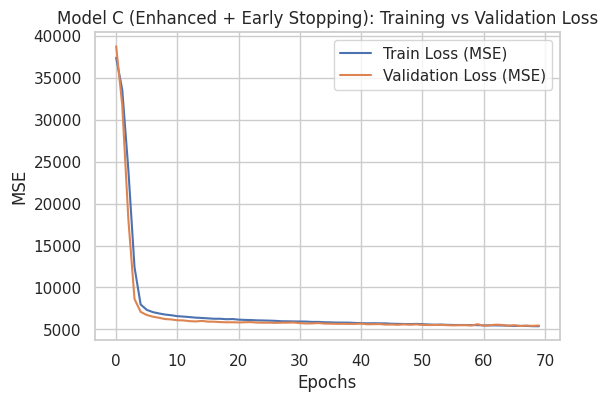

In [184]:
# Plot training curves for Model C
plot_training_curves(hist_c, model_name="Model C (Enhanced + Early Stopping)")

Model C uses the same deeper architecture as Model B (128 → 64 nodes) but trains on the enhanced feature set and uses EarlyStopping (patience=5, restore_best_weights=True) to prevent overfitting.

---
## 7. Model Comparison
Side-by-side metrics and learning curves for all three models.

In [ ]:
# Side-by-side comparison of all three models
print("=" * 65)
print(f"{'Model':<30} {'MAE':>8} {'RMSE':>8} {'R²':>8}")
print("=" * 65)
print(f"{'Model A (Baseline)':<30} {round(mae_a,2):>8} {round(rmse_a,2):>8} {round(r2_a,2):>8}")
print(f"{'Model B (Deeper)':<30} {round(mae_b,2):>8} {round(rmse_b,2):>8} {round(r2_b,2):>8}")
print(f"{'Model C (Enhanced + ES)':<30} {round(mae_c,2):>8} {round(rmse_c,2):>8} {round(r2_c,2):>8}")
print("=" * 65)

In [ ]:
# Bar chart comparison of model metrics
import pandas as pd

results_df = pd.DataFrame({
    'Model': ['A (Baseline)', 'B (Deeper)', 'C (Enhanced + ES)'],
    'MAE': [mae_a, mae_b, mae_c],
    'RMSE': [rmse_a, rmse_b, rmse_c],
    'R²': [r2_a, r2_b, r2_c]
})

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].bar(results_df['Model'], results_df['MAE'], color=['steelblue', 'coral', 'seagreen'])
axes[0].set_title('MAE by Model')
axes[0].set_ylabel('MAE')

axes[1].bar(results_df['Model'], results_df['RMSE'], color=['steelblue', 'coral', 'seagreen'])
axes[1].set_title('RMSE by Model')
axes[1].set_ylabel('RMSE')

axes[2].bar(results_df['Model'], results_df['R²'], color=['steelblue', 'coral', 'seagreen'])
axes[2].set_title('R² by Model')
axes[2].set_ylabel('R²')

plt.tight_layout()
plt.show()

Comparison table and bar charts showing MAE, RMSE, and R² across all three models. Model B (Deeper) achieved the best overall performance with the lowest MAE and RMSE, and the highest R².

---
## 8. Discussion and Business Insights

**Which model performs best, and why?**

Model B (Deeper Neural Network) achieved the best performance with the lowest MAE (55.14), lowest RMSE (80.85), and highest R² (0.51). The added hidden layer gave the model more capacity to learn complex relationships between features and price compared to the single-layer baseline. However, the improvement over Model A is modest, suggesting that the baseline architecture already captured most of the learnable patterns from these features.

**Did the new features improve predictions?**

Model C, which included the new features (amenities_count, host_total_listings_count, minimum_nights) along with early stopping, did not outperform Models A or B. Its R² (0.48) was slightly lower than both. This suggests that the additional features, while intuitively relevant, did not add significant predictive power beyond what the original features already captured. Early stopping may have also limited training by halting before the model fully converged. The weak correlations between the new features and price observed in the correlation matrix support this outcome.

**Other insights**

Property size features (bedrooms, bathrooms, accommodates) remain the strongest predictors of price, consistent with Assignment 1 findings. The fact that amenities count did not strongly improve predictions suggests that the number of amenities alone may not capture quality — the type of amenities (e.g., pool vs. hangers) likely matters more. Host scale (host_total_listings_count) showed minimal impact on pricing, indicating that professional and individual hosts price similarly in the Asheville market. Overall, the models explain roughly half of price variance, suggesting that factors not in the dataset (location specifics, seasonality, listing photos/descriptions) play a significant role in Airbnb pricing.